# Hydrogenic Atoms without charge

Pretend that the electrons and nuclei did not have charge, but only mass. What would atoms look like? How big is the "correction" (as a perturbation) due to gravitational attraction for 1- and 2-electron atoms?

## &#x1f469;&#x1f3fd;&#x200d;&#x1f4bb; Notebook on Gravitational one and two electron atoms


1. Plot the radial probabilities for the Hydrogenic orbitals.
1. Make contour plots of the 2p orbitals.
1. Calculate the first order perturbation for He atom


## Visualizing the Radial Probability Distribution for Hydrogenic Orbitals

Assuming the Born-Oppenheimer approximation, the Hamiltonian of 1-electron atom (in atomic units) is given by:

$$
\hat{H}_{\text{1 el. atom}} = -\frac{1}{2} \nabla^2 - \frac{Z}{r}
$$

The corresponding Schr&ouml;dinger equation in spherical coordinates is written as:

$$
\left(-\frac{1}{2} \left( \frac{d^2}{dr^2}
+ \frac{2}{r} \frac{d}{dr}\right)
      + \frac{\hat{L}^2}{2r^2} - \frac{Z}{r} \right)
      \psi_{n,l,m_l}(r,\theta,\phi)
= E_{n,l,m_l}\psi_{n,l,m_l}(r,\theta,\phi)
$$

Using the technique of separation of variables, the wave-function of 1-electron atom has the form:

$$
\psi_{n,l,m}(r,\theta,\phi) = R_{n,l}(r) Y_l^{m}(\theta,\phi)
$$

Solving the Schr&ouml;dinger equation, the eigenfunctions and eigenenergies of the 1-electron atoms are obtained. The radial and angular components of the wavefunction are discussed in the following sections which are described by quantum numbers

$$
\text{principle quantum number:} \quad n=1,2,3,\ldots \\
\text{angular momentum quantum number:} \quad l=0,1,\ldots,n-1 \\
\text{magnetic quantum number:} \quad m = 0,\pm 1, \pm2, \ldots, \pm l
$$

The eigenenergies of the 1-electron wavefunctions are

$$
E_n = -\frac{Z^2}{2n^2}
$$

The eigenenergies of the Hydrogenic wavefunctions do not depend on $m$ or $l$. So there are $(n+1)^2$ degenerate eigenfunctions.

For further review, see [The Schrödinger Wave Equation for the Hydrogen Atom](<https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Map%3A_Physical_Chemistry_for_the_Biosciences_(Chang)/11%3A_Quantum_Mechanics_and_Atomic_Structure/11.10%3A_The_Schrodinger_Wave_Equation_for_the_Hydrogen_Atom>).


### The radial component of the hydrogenic wavefunction is given by:

$$ R_{nl}(r) = \sqrt{\Big(\frac{2Z}{n a_0}\Big)^3 \frac{(n-l-1)!}{2n (n+l)!}} e^{-Zr/n a_0} \Big( \frac{2Zr}{na_0}\Big)^l \cdot L^{2l+1}_{n-l-1} \Big(\frac{2Zr}{n a_0} \Big)$$

- $R_{nl}(r)$ has $(n - l - 1)$ nodes.
- The $L$ denotes the [associated Laguerre polynomials](https://en.wikipedia.org/wiki/Laguerre_polynomials) computed by [scipy.special.assoc_laguerre](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.assoc_laguerre.html).
- The Bohr radius (atomic unit of length) is one; i.e., $a_0=1$.

For further review, see [Radial and Angular Parts of Atomic Orbitals](<https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Quantum_Mechanics/10%3A_Multi-electron_Atoms/Radial_and_Angular_Parts_of_Atomic_Orbitals>).


###**Change of perspective: What if atoms did not have charge, but mass only. How would the radial probabilities, orbitals and interactions change?**

If electrons and protons did not have charge, there would be no electrostatic attraction or repulsion between the particles. From the hydrogen atom, Coulomb potential needs to be removed. $$\frac{e^2}{4\pi\epsilon_0}\frac{Z}{r}$$
in atomic units, this is simply represented by $\frac{Z}{r}$ in this workbook.

The new potential of interest is the gravitational potential, this is:$$\frac{-GMm}{r}$$

The function $\frac{1}{r}$ is consistent between these potentials. In this regard, the math performed is the same, but the constant are very different (coulomb vs gravitational).

In this workbook, it operates with the Bohr radius, $a_0=1$, or $a_o=\frac{\hbar^2}{k_eme^2}$ this is no longer true for the gravitational atoms. It is adjusted such that:

$$a_g = \frac{\hbar^2}{GMm^2}$$

This equation is made by substituting the electrostatic coupling constant $k_ee^2$ with the gravitational coupling constant $GMm$.


The radial function itself, is identical between coloumb and gravitational models, they both have a function of 1/r. The thing that is changing is the scaling between $a_o$ and $a_g$

**Note:** The radial component of the hydrogenic wavefunction is given by:

$$ R_{nl}(r) = \sqrt{\Big(\frac{2Z}{n a_0}\Big)^3 \frac{(n-l-1)!}{2n (n+l)!}} e^{-Zr/n a_0} \Big( \frac{2Zr}{na_0}\Big)^l \cdot L^{2l+1}_{n-l-1} \Big(\frac{2Zr}{n a_0} \Big)$$
Notice that there are terms of: $\frac{value}{na_0}$ in the new gravitational atoms, these need to be **$\frac{value}{na_g}$**

in the plotting code block, needed to adjust the plot boundaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

In [2]:
def radial(r, n, l, Z=1):
    """
    Compute the radial part of the hydrogenic wavefunction.

    Parameters
    ----------
    r : float
        The radial distance from the nucleus.
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    Z : int
        The atomic number.

    Returns
    -------
    float
        The value of the radial wavefunction at r.
    """
    # Physical Constants (SI Units)
    G = 6.67430e-11      # Gravitational constant
    M = 1.6726219e-27    # Mass of a proton (kg)
    m = 9.10938356e-31   # Mass of an electron (kg)
    hbar = 1.0545718e-34 # Reduced Planck constant

    # Gravitational Bohr Radius (This replaces 'a0' in the original math)
    a_g = (hbar**2) / (G * M * m**2)

    ## computing normalization constant

def radial(r, n, l, Z=1):
    ## 1. Normalization:
    norm = np.sqrt((Z*2 / (n * a_g))**3 * special.factorial(n-l-1) / (2 * n * special.factorial(n+l)))

    ## 2. Exponent:
    exp = np.exp(-Z*r / (n * a_g))

    ## 3. Polynomial and Laguerre: Replace 2*Z*r/n with 2*r / (n*a_g)
    rho = 2 * Z * r / (n * a_g)
    polynomial = rho**l
    lag = special.assoc_laguerre(rho, n-l-1, 2*l+1)

    return norm * exp * polynomial * lag

def compute_radial_prob(r, n, l, Z=1):
    """
    Compute the radial probability density of the hydrogenic wavefunction.

    Parameters
    ----------
    r : float
        The radial distance from the nucleus.
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    Z : int
        The atomic number.

    Returns
    -------
    float
        The probability density at r.
    """
    ### START YOUR CODE HERE ###
    ## computing probability density
    return radial (r, n, l, Z)**2 * r**2 * 4 *np.pi
    ### END YOUR CODE HERE ###

$$ R_{nl}(r) = \sqrt{\Big(\frac{2Z}{n a_g}\Big)^3 \frac{(n-l-1)!}{2n (n+l)!}} e^{-Zr/n a_g} \Big( \frac{2Zr}{na_g}\Big)^l \cdot L^{2l+1}_{n-l-1} \Big(\frac{2Zr}{n a_g} \Big)$$

Normalization portion: $$\sqrt{\Big(\frac{2Z}{n a_g}\Big)^3 \frac{(n-l-1)!}{2n (n+l)!}}$$

Exponent part: $$e^{-Zr/n a_g} \Big( \frac{2Zr}{na_g}\Big)^l$$
Laguerre polynomial
$$L^{2l+1}_{n-l-1} \Big(\frac{2Zr}{n a_g} \Big)$$

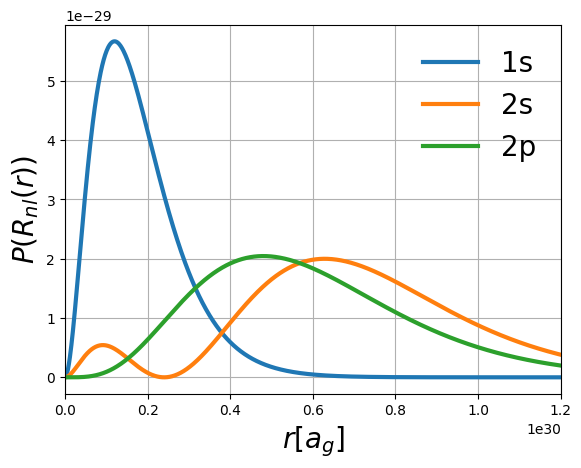

In [3]:
# Physical Constants (SI Units)
G = 6.67430e-11      # Gravitational constant
M = 1.6726219e-27    # Mass of a proton (kg)
m = 9.10938356e-31   # Mass of an electron (kg)
hbar = 1.0545718e-34 # Reduced Planck constant
a_g = (hbar**2) / (G * M * m**2)
r = np.linspace(0, 10*a_g, 1000)

# plot r vs. prob R(r)
plt.plot(r, compute_radial_prob(r, n=1, l=0), lw=3, label="1s")
plt.plot(r, compute_radial_prob(r, n=2, l=0), lw=3, label="2s")
plt.plot(r, compute_radial_prob(r, n=2, l=1), lw=3, label="2p")

plt.xlabel("$r [a_g]$",fontsize=20)
plt.ylabel("$P(R_{nl}(r))$", fontsize=20)
plt.grid("True")
plt.legend(frameon=False, fontsize=20)
plt.xlim(0, 10*a_g)
plt.show()

For this plot, radial probabilities, note the scale of the x and y axis: 1e30. The radius of this atom, without charged subatomic particles is 1e30. Gravitational is an extremely weak force to hold together the atom as compared to electrostatic. For context, the observable universe is 8.8e26 m. This atom would need ot be larger than the universe to stay bound.

x-axis, distance from center
y-axis, probability
1s (blue), most tightly bound, closes to nucleus
2s (orange), one node, closer to nucleus has higher energy (less probable), particle is more likely to be found at hump further away from nucleus
2p (green), no nodes, peaks similar but slightly less than the 2s

## Visualizing the Angular Wavefunction for Hydrogenic Orbitals

The angular component of the hydrogenic wavefunction is given by spherical harmonics:

$$
Y_{lm}(\theta,\phi) = \Theta_{lm}(\theta) \Phi_m (\phi) = \sqrt{\frac{2l+1}{4\pi} \frac{(l-m)!}{(l+m)!} } P_{lm}(cos \theta) \cdot e^{im\phi}
$$

- $Y_{lm}(\theta,\phi)$ has $l$ nodes.
- The $P$ are the associated Legendre functions.
- The spherical harmonics are computed by [scipy.special.sph_harm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.sph_harm.html).

For further review, see [Radial and Angular Parts of Atomic Orbitals](<https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Quantum_Mechanics/10%3A_Multi-electron_Atoms/Radial_and_Angular_Parts_of_Atomic_Orbitals>).

**Note:** that the orbital images that appear above do not look that much like the usual orbital pictures, with the exception of the $m=0$ orbitals. This is because of the complex-valuedness. We often instead use the _real_ spherical harmonics, which are defined simply as:

$$
\begin{align}
S_l^{m>0}(\theta,\phi) &= \frac{1}{\sqrt{2}} \left(Y_l^{-m} (\theta, \phi) + (-1)^{m} Y_l^{m} (\theta, \phi) \right) \\
S_l^{m=0}(\theta,\phi) &= Y_l^{m=0} (\theta, \phi) \\
S_l^{m<0}(\theta,\phi) &= \frac{i}{\sqrt{2}} \left(Y_l^{-m} (\theta, \phi) - (-1)^{m} Y_l^{m} (\theta, \phi) \right)
\end{align}
$$

The following animations shows one can take linear combinations of the (complex) spherical harmonics to form the $p_x$, $p_y$, etc. orbitals one generally uses in chemistry.

![animation of 2p orbital](https://github.com/PaulWAyers/IntroQChem/blob/main/linkedFiles/Orbital_p1-px_animation.gif?raw=true "animation of 2p real and complex orbitals; by Geek3 CC-SA4 license")

![animation of 3p orbital](https://github.com/PaulWAyers/IntroQChem/blob/main/linkedFiles/Orbital_3p1-3px_animation.gif?raw=true "animation of 3p real and complex orbitals; by Geek3 CC-SA4 license")

Using the [orbitron](https://winter.group.shef.ac.uk/orbitron/atomic_orbitals/7i/index.html), you can visualize the (real, Cartesian) spherical harmonics.


In [21]:
def spherical(theta, phi, l, m):
    """
    Compute the spherical harmonic function.

    Parameters
    ----------
    theta : float
        The polar angle.
    phi : float
        The azimuthal angle.
    l : int
        The angular momentum quantum number.
    m : int
        The magnetic quantum number.

    Returns
    -------
    harm: complex
        The value of the spherical harmonic function at given theta and phi.
    """
    ### START YOUR CODE HERE ###
    # calculating the spherical harmonic function using scipy.special.sph_harm
    harm = special.sph_harm(m, l, phi, theta)
    return harm
    ### END YOUR CODE HERE ###

def hydrogenic_wavefunction(r, theta, phi, n, l, m, Z=1):
    """
    Compute the hydrogenic wavefunction.

    Parameters
    ----------
    r : float
        The radial distance from the nucleus.
    theta : float
        The polar angle.
    phi : float
        The azimuthal angle.
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    m : int
        The magnetic quantum number.
    Z : int
        The atomic number.

    Returns
    -------
    float
        The value of the hydrogenic wavefunction at given r, theta, and phi.
    """
    ### START YOUR CODE HERE ###
    # compute the wavefunction using the radial and spherical parts
    return radial(r, n, l, Z) * spherical(theta, phi, l, m)
    ### END YOUR CODE HERE ###

/tmp/ipykernel_6361/2974134069.py:23: RuntimeWarning: floating point number truncated to an integer
  harm = special.sph_harm(m, l, phi, theta)
/tmp/ipykernel_6361/2974134069.py:23: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  harm = special.sph_harm(m, l, phi, theta)


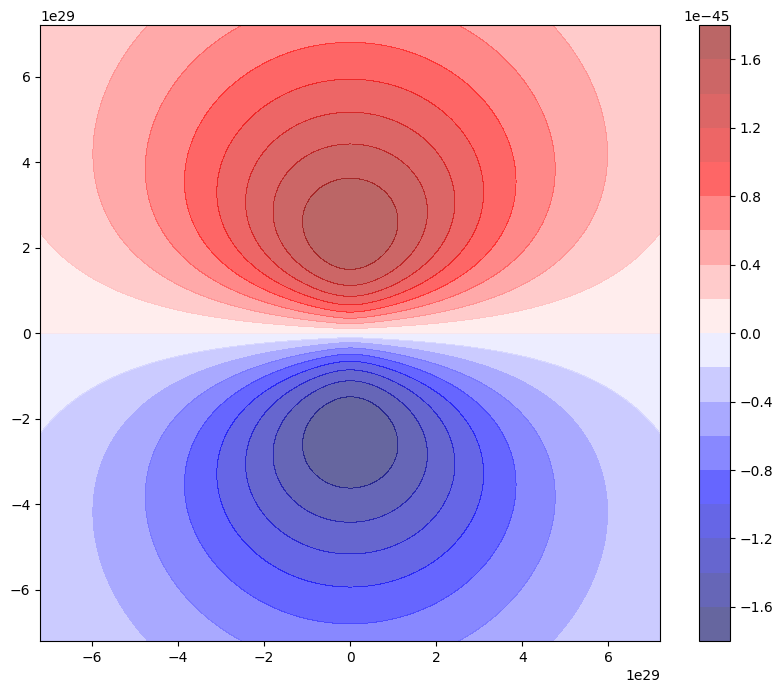

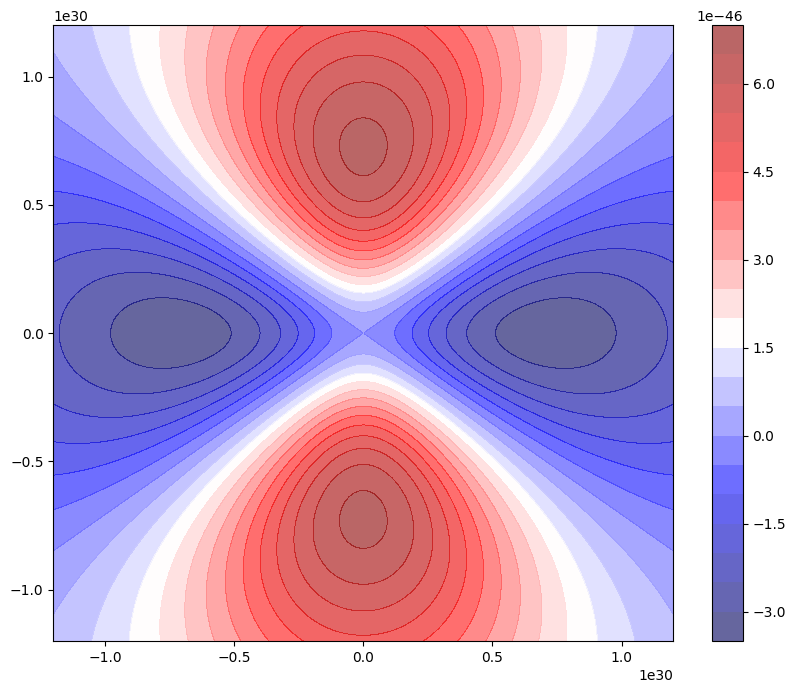

In [24]:
def psi_xz_plot(n=1, l=0, m=0, N=500):
    """
    Plot the hydrogenic wavefunction in the xz-plane.

    Parameters
    ----------
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    m : int
        The magnetic quantum number.
    N : int
        The number of points on the grid.

    Returns
    -------
    None
    """
    # Physical Constants (SI Units)
    G = 6.67430e-11      # Gravitational constant
    M = 1.6726219e-27    # Mass of a proton (kg)
    m = 9.10938356e-31   # Mass of an electron (kg)
    hbar = 1.0545718e-34 # Reduced Planck constant
    a_g = (hbar**2) / (G * M * m**2)

    plt.figure(figsize=(10, 8))
    limit = 2 * (n + l)*a_g

    # create a grid of points in the xz-plane
    ### START YOUR CODE HERE ###
    # create array of uniformly spaced points in x and z
    # from -limit to limit with 500 points
    x_1d = np.linspace(-limit, limit, N)
    z_1d = np.linspace(-limit, limit, N)

    # create a 2D meshgrid for the x and z points
    x, z = np.meshgrid(x_1d, z_1d)
    y = 0.0

    # convert the 2D meshgrid to spherical coordinates
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / (r+1e-60))
    phi = np.arctan2(y, x)

    # compute the real part of hydrogenic wavefunction
    psi_nlm = hydrogenic_wavefunction(r, theta, phi, n, l, m).real

    ### END YOUR CODE HERE ###
    # classic orbitals
    plt.contourf(x, z, psi_nlm, 20, cmap="seismic", alpha=0.6)  # Classic orbitals
    plt.colorbar()

    return psi_nlm

psi = psi_xz_plot( 2, 1, 0)
psi = psi_xz_plot( 3, 2, 0)

np.acrtan provides a zero argument, handles divide by zero in sensible way.
what if y and x are =0? Then this function (arctan 2) will make it work.

Here the 2p lobes are shown, one angular node. Dark regions of the nodes are regions where wavefunction has highest amplitude.

The shape of this plot is the same as the hydrogen atom with charge, the thing that has changed is the scale between them.

## Compute the Gravitational Interactions Between two Hydrogenic Orbitals, without charge

Want to look at an excited 2 electron system $1s^12s^1$. Need to know the gravitational potential energy from their overlap.

Direct Integral $J_{1s,2s}$, classical attraction between masses
   $$
   J_{1 \mathrm{~s}, 2 \mathrm{~s}}=\int \frac{(1 \mathrm{~s})^2\left(\mathbf{x}_1\right)(2 \mathrm{~s})^2\left(\mathbf{x}_2\right)}{r_{12}} d \mathbf{x}_1 d \mathbf{x}_2
   $$

This can be simplified with Laplace expansion to:
This is a six dimensional integral. However, it can be simplified via the Laplace
expansion of $\frac{1}{r_{12}}$,

\begin{aligned}
& =\int_0^{\infty} \int_0^{\infty} \frac{1}{r_{>}} R_{1,0}^2\left(r_1\right) R_{2,0}^2\left(r_2\right) r_1^2 r_2^2 d r_1 d r_2 \\
&
\end{aligned}



**Key difference with graviational potential, it is an attractive force between the particles, unlike coulomb potential. Attractive force is represented by a negative sign, increase in stability with overlap**

###Calculating the Perturbation for a 2-electron atom in the ground state
In the ground state, only the direct integral needs to be considered.
Here the first order energy correction is calculated.

In [25]:
def integrate_grid(grid_func, rmin=1e-22, rmax=15*a_g, n_points=1000):
    """
    Integrate a given grid function.

    Parameters
    ----------
    grid_func : function
        The function to be integrated.
    rmin : float
        The minimum value of the radial distance.
    rmax : float
        The maximum value of the radial distance.
    n_points : int
        The number of points in the grid.

    Returns
    -------
    float
        The value of the integral.
    """
    ### create vectors  r1 and r2  of size n_points ranging from rmin to rmax
    r1 = np.linspace(rmin, rmax, n_points)
    r2 = np.linspace(rmin, rmax, n_points)

    ### START YOUR CODE HERE ###
    ### evaluate the grid for the specified grid function
    grid = grid_func(r1, r2)

    ### calculate the dr1 and dr2
    dr1 = r1[1] - r1[0]
    dr2 = r2[1] - r2[0]

    ### perform integration by suming up all the values on the grid
    ### and multiply them by dr1 and dr2
    result = np.sum(grid) * dr1 * dr2

    return result
    ### END YOUR CODE HERE ###

In [20]:
def perturbation_ground_state(r1, r2):
    """
    Integrand for the ground state perturbation (J_1s1s).
    """
    r1, r2 = np.meshgrid(r1, r2)

    # Evaluate 1s density for both positions
    R1s_sq_r1 = radial(r1, 1, 0, Z=2)**2
    R1s_sq_r2 = radial(r2, 1, 0, Z=2)**2

    r_max = np.maximum(r1, r2)

    # Geometric integrand
    return (R1s_sq_r1 * R1s_sq_r2 * r1**2 * r2**2) / r_max

# Calculate the energy shift
geom_J_ground = integrate_grid(perturbation_ground_state)
E_perturbation_ground = geom_J_ground * (-G * 4*M * m)

print(f"Ground State Perturbation Energy: {E_perturbation_ground} Joules")

Ground State Perturbation Energy: -4.235626986717692e-96 Joules


Two non excited, 1s orbital electrons, in Z=2 (He), total graviational potential includes 2p+2n (4*M)

#Summary: Physical Interpretation of the Gravitational Perturbation
The calculated first-order energy perturbation for the ground state ($1s^2$) is approximately $-4.24 \times 10^{-96}$ Joules. This value represents the amount of E associated with graviational potential energy of 2 electrons in a ground state He atom, where the electrons do not have charge.

Key Takeaways:


1.   Direct Interaction ($J$): In this 1st-order perturbation model, the energy shift is derived entirely from the Direct Integral. This accounts for the energy gained by placing two mass distributions within each other's gravitational fields.
2.   Gravitational attraction is much much weaker attraction than the electron-electron repulsion.
3. Stability: Because the perturbation is negative, the gravitational attraction technically makes the atom more stable (more tightly bound) than a system of two independent non-interacting electrons.
4. Limitations of 1st-Order Theory: This calculation assumes the "shapes" of the $1s$ orbitals remain static. A higher-level Hartree-Fock approach would allow the orbitals to physically contract in response to this attraction, though the resulting change in energy would be numerically indistinguishable at this scale.